In [ ]:
# 1) Imports e leitura
# https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Ajuste o caminho para o arquivo no Colab (faça upload do ai4i2020.csv)
PATH = "/content/ai4i2020.csv"   # no Colab: faça upload e ajuste se necessário
df = pd.read_csv(PATH)
print("Arquivo lido:", PATH)
print("Shape:", df.shape)
display(df.head(6))
print("\nDtypes:\n", df.dtypes)

Arquivo lido: /content/ai4i2020.csv
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0



Dtypes:
 UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [ ]:
# 2) Contexto e variáveis (resumo automático)
print("Colunas:\n", list(df.columns))
print("\nResumo rápido:")
display(df.describe(include='all').T)


Colunas:
 ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Resumo rápido:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


In [ ]:
# 3) Limpeza: missing, duplicados
print("Missing por coluna:\n", df.isna().sum())
dups = df.duplicated().sum()
print("Linhas duplicadas exatas:", dups)
if dups>0:
    df = df.drop_duplicates()
    print("Duplicados removidos. Novo shape:", df.shape)

# Imputação simples (se houver missing)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if df[num_cols].isna().sum().sum() > 0:
    print("Imputando numéricos pela mediana...")
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for c in cat_cols:
    if df[c].isna().sum()>0:
        df[c] = df[c].fillna(df[c].mode().iloc[0])
print("Missing agora:", df.isna().sum().sum())


Missing por coluna:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Linhas duplicadas exatas: 0
Missing agora: 0


In [ ]:
# 4) Outliers — flag por IQR (não removemos automaticamente; só marcamos)
outlier_flags = pd.DataFrame(index=df.index)
outlier_counts = {}
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    is_out = (df[c] < lower) | (df[c] > upper)
    outlier_flags[c + "_outlier"] = is_out
    outlier_counts[c] = is_out.sum()
print("Outliers detectados (IQR) por coluna (contagem):")
for k,v in outlier_counts.items():
    print(f" - {k}: {v}")
print("Linhas com ao menos 1 outlier:", outlier_flags.any(axis=1).sum())


Outliers detectados (IQR) por coluna (contagem):
 - UDI: 0
 - Air temperature [K]: 0
 - Process temperature [K]: 0
 - Rotational speed [rpm]: 418
 - Torque [Nm]: 69
 - Tool wear [min]: 0
 - Machine failure: 339
 - TWF: 46
 - HDF: 115
 - PWF: 95
 - OSF: 98
 - RNF: 19
Linhas com ao menos 1 outlier: 744


# Normalizando os dados


In [ ]:

from sklearn.preprocessing import StandardScaler

# Definir colunas alvo
target_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Selecionar apenas colunas numéricas que não sejam alvo
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in target_cols]

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols, index=df.index)

print("Padronização feita apenas nas colunas numéricas preditoras.")




Padronização feita apenas nas colunas numéricas preditoras.


In [ ]:
# Estatística descritiva corrigida (média, mediana, moda, variância, desvio, amplitude)
desc = df[num_cols].describe().T        # describe traz: count, mean, std, min, 25%, 50%, 75%, max
modes = df[num_cols].mode().iloc[0]     # moda por coluna

# calcule variância e amplitude separadamente
variance = df[num_cols].var()           # variância (padrão pandas: ddof=1)
amplitude = desc['max'] - desc['min']

# anexe as novas colunas ao desc
desc['mode'] = modes
desc['variance'] = variance
desc['amplitude'] = amplitude

# renomeie 50% para median para ficar legível e selecione as colunas que existem
to_show = ['mean', '50%', 'mode', 'std', 'variance', 'min', 'max', 'amplitude']
display(desc[to_show].rename(columns={'50%':'median', 'std':'std'}))


,mean,median,mode,std,variance,min,max,amplitude
UDI,5000.50000,5000.5,1.0,2886.895680,8.334167e+06,1.0,10000.0,9999.0
Air temperature [K],300.00493,300.1,300.7,2.000259,4.001035e+00,295.3,304.5,9.2
Process temperature [K],310.00556,310.1,310.6,1.483734,2.201467e+00,305.7,313.8,8.1
Rotational speed [rpm],1538.77610,1503.0,1452.0,179.284096,3.214279e+04,1168.0,2886.0,1718.0
Torque [Nm],39.98691,40.1,40.2,9.968934,9.937964e+01,3.8,76.6,72.8
Tool wear [min],107.95100,108.0,0.0,63.654147,4.051850e+03,0.0,253.0,253.0


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000


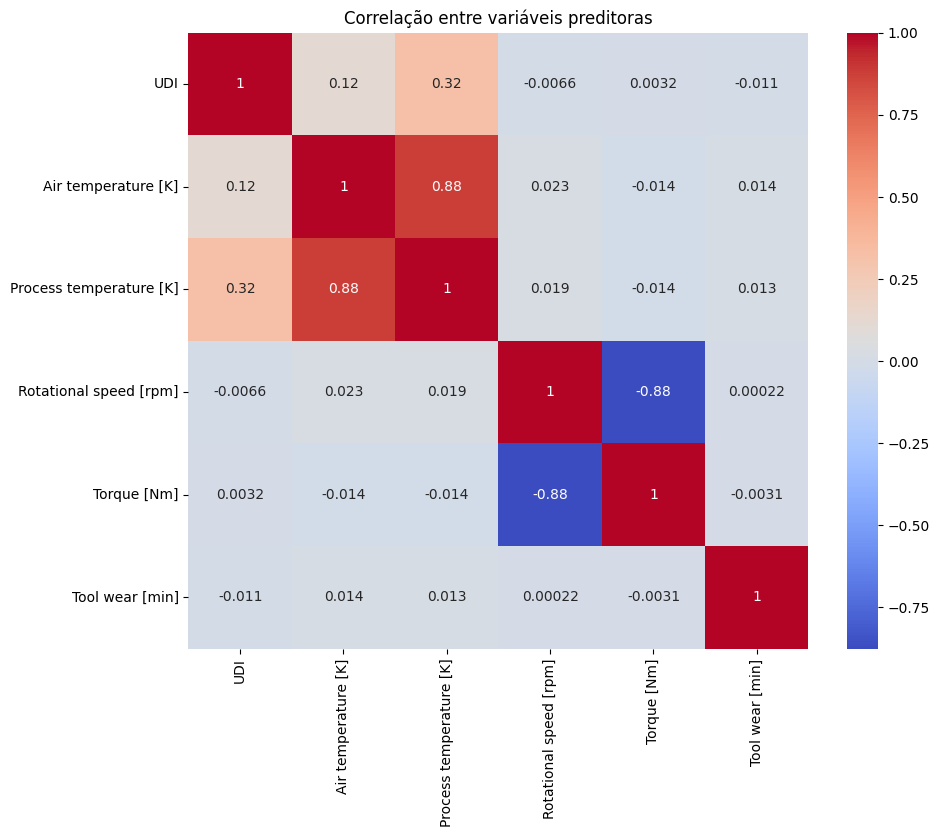

Pares com |corr|>0.6:
 - Air temperature [K] <-> Process temperature [K]: r = 0.876
 - Rotational speed [rpm] <-> Torque [Nm]: r = -0.875


In [ ]:
# 7) Correlação de Pearson e heatmap
import seaborn as sns
corr = df[num_cols].corr(method='pearson')
display(corr)


plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlação entre variáveis preditoras")
plt.show()


# Pares com correlação forte |r| > 0.6
strong = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr.values[i,j]
        if abs(r) > 0.6:
            strong.append((num_cols[i], num_cols[j], r))
print("Pares com |corr|>0.6:")
for a,b,r in strong:
    print(f" - {a} <-> {b}: r = {r:.3f}")


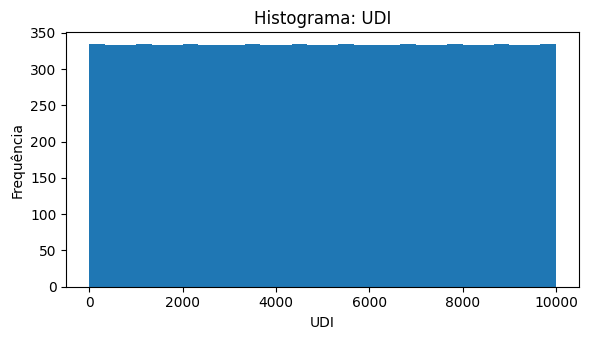

Interpretação rápida: média=5000.500, mediana=5000.500



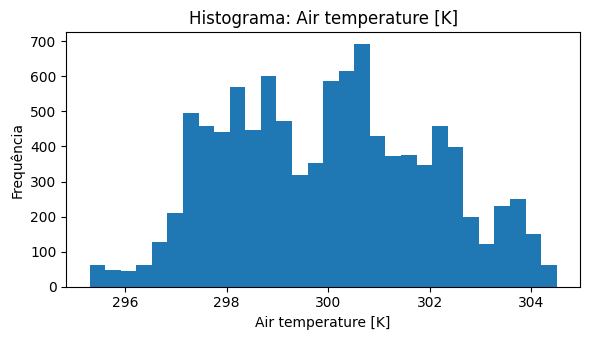

Interpretação rápida: média=300.005, mediana=300.100



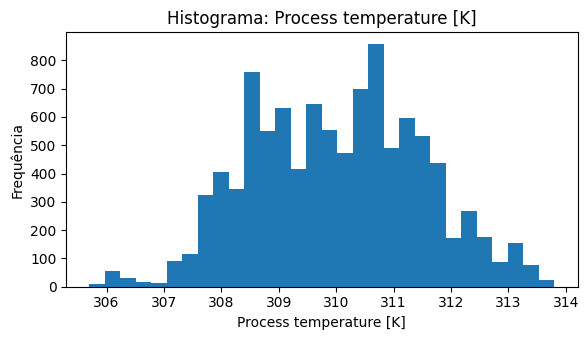

Interpretação rápida: média=310.006, mediana=310.100



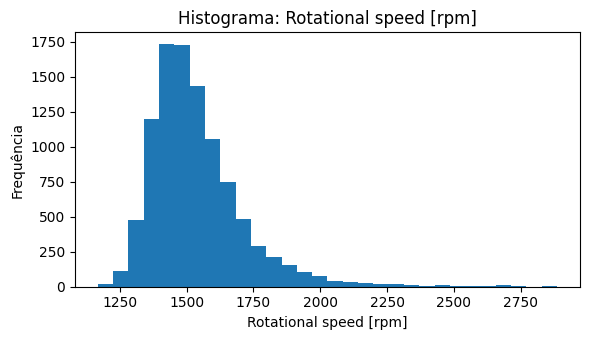

Interpretação rápida: média=1538.776, mediana=1503.000



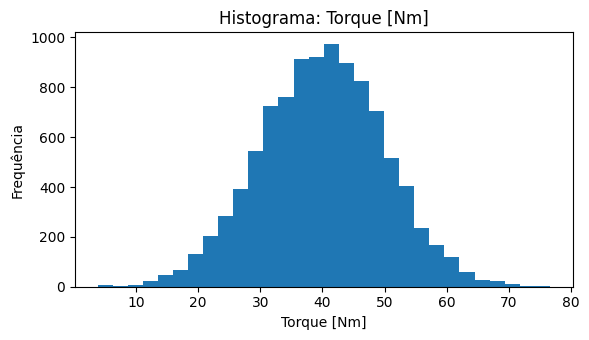

Interpretação rápida: média=39.987, mediana=40.100



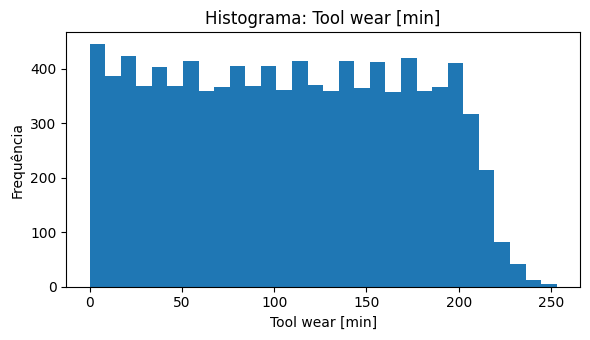

Interpretação rápida: média=107.951, mediana=108.000



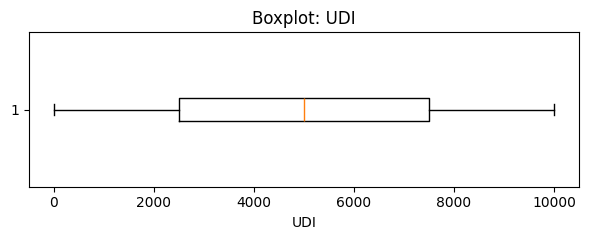

Interpretação: UDI - outliers (IQR) detectados: 0


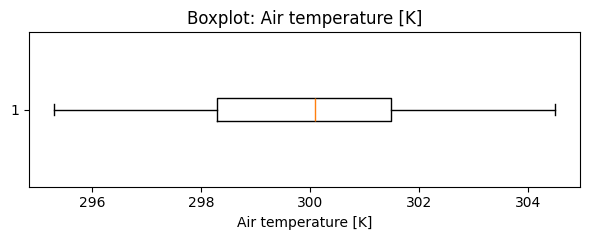

Interpretação: Air temperature [K] - outliers (IQR) detectados: 0


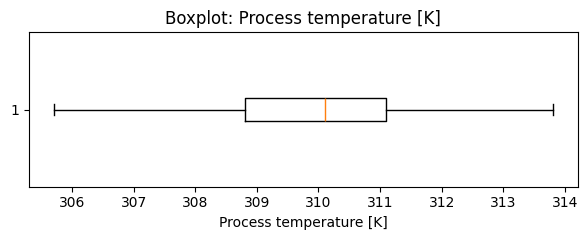

Interpretação: Process temperature [K] - outliers (IQR) detectados: 0


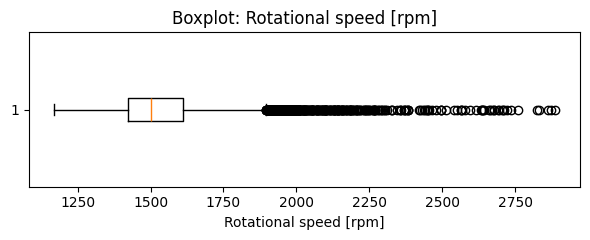

Interpretação: Rotational speed [rpm] - outliers (IQR) detectados: 418


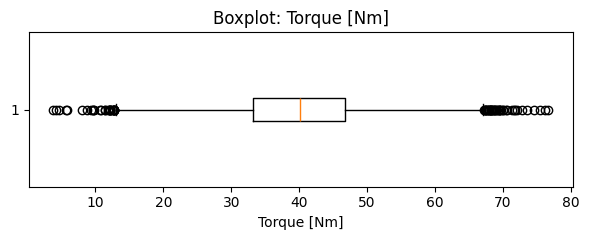

Interpretação: Torque [Nm] - outliers (IQR) detectados: 69


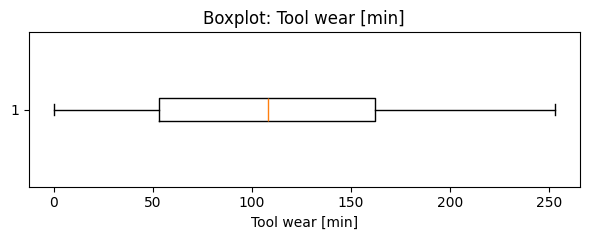

Interpretação: Tool wear [min] - outliers (IQR) detectados: 0


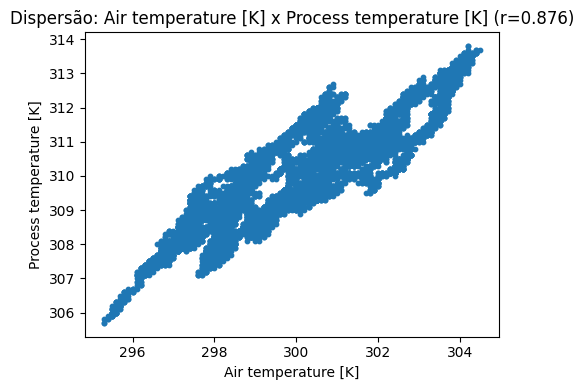

Interpretação: relação entre Air temperature [K] e Process temperature [K] — correlação r=0.876



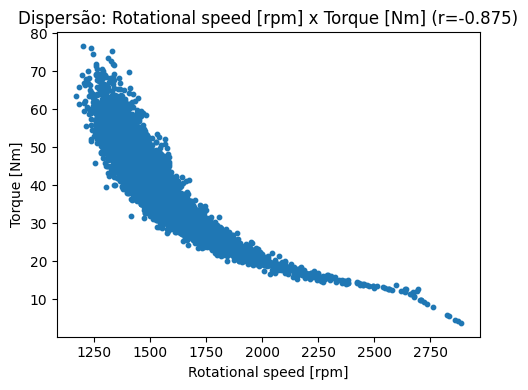

Interpretação: relação entre Rotational speed [rpm] e Torque [Nm] — correlação r=-0.875



In [ ]:
# 8) Visualizações (histogramas, boxplots, scatter para pares fortes)
# IMPORTANTE: cada gráfico é exibido separadamente — execute com calma.
for c in num_cols:
    plt.figure(figsize=(6,3.5))
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histograma: {c}")
    plt.xlabel(c); plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()
    print(f"Interpretação rápida: média={df[c].mean():.3f}, mediana={df[c].median():.3f}\n")

for c in num_cols:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot: {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()
    print(f"Interpretação: {c} - outliers (IQR) detectados: {outlier_counts[c]}")

# Scatter para pares fortes (máx 6 pares)
pairs = strong[:6] if len(strong)>0 else []
if len(pairs)==0:
    # pega os 6 primeiros pares quaisquer
    cols = num_cols[:4]
    pairs = []
    for i in range(len(cols)):
        for j in range(i+1,len(cols)):
            pairs.append((cols[i], cols[j], corr.loc[cols[i],cols[j]]))
            if len(pairs)>=6: break
        if len(pairs)>=6: break
for a,b,r in pairs:
    plt.figure(figsize=(5,4))
    plt.scatter(df[a], df[b], s=10)
    plt.xlabel(a); plt.ylabel(b)
    plt.title(f"Dispersão: {a} x {b} (r={r:.3f})")
    plt.tight_layout()
    plt.show()
    print(f"Interpretação: relação entre {a} e {b} — correlação r={r:.3f}\n")


In [ ]:
# 9) Identificar atributos relevantes (heurística: variância + correlação com alvo se existir)
cand_targets = [c for c in df.columns if 'failure' in c.lower() or 'target' in c.lower() or 'tool_wear' in c.lower()]
print("Possíveis colunas alvo:", cand_targets)
var_sorted = df[num_cols].var().sort_values(ascending=False)
print("Top variáveis por variância:")
print(var_sorted.head(10))
# Se houver um alvo binário, calcule correlação com o alvo
if len(cand_targets)>0:
    target = cand_targets[0]
    corr_with_target = df[num_cols].corrwith(df[target]).abs().sort_values(ascending=False)
    print("\nCorrelação absoluta com alvo (%s):" % target)
    print(corr_with_target.head(10))


Possíveis colunas alvo: ['Machine failure']
Top variáveis por variância:
UDI                        8.334167e+06
Rotational speed [rpm]     3.214279e+04
Tool wear [min]            4.051850e+03
Torque [Nm]                9.937964e+01
Air temperature [K]        4.001035e+00
Process temperature [K]    2.201467e+00
dtype: float64

Correlação absoluta com alvo (Machine failure):
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]     0.044188
Process temperature [K]    0.035946
UDI                        0.022892
dtype: float64


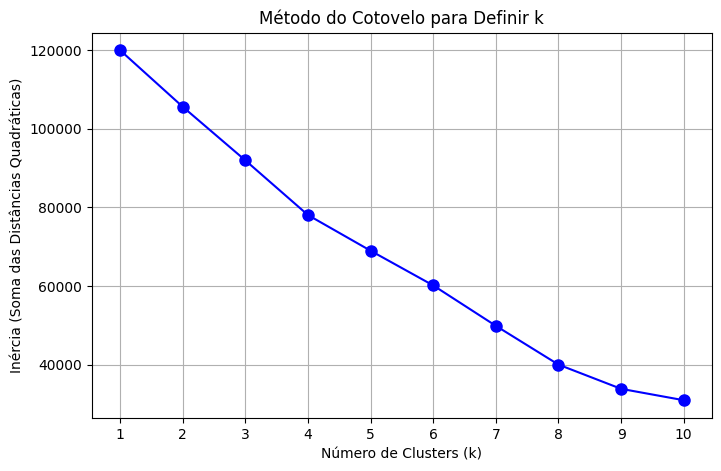

In [ ]:
# grafico do cotovelo
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Selecionar apenas colunas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(df[num_cols])

# Calcular inércia para diferentes valores de k
inertias = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Soma das Distâncias Quadráticas)')
plt.title('Método do Cotovelo para Definir k')
plt.xticks(K)
plt.grid(True)
plt.show()


Melhor k segundo silhouette: 4


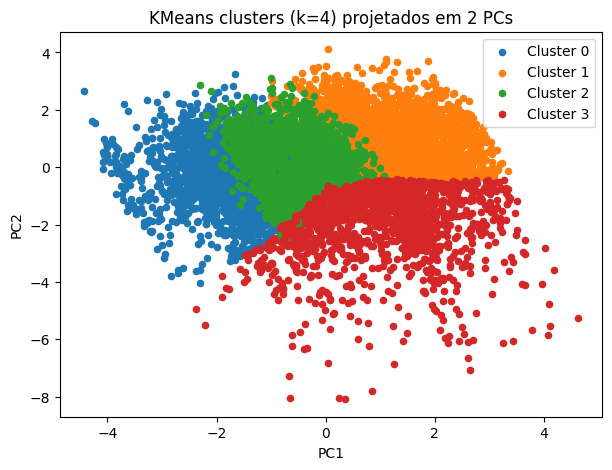

In [ ]:
# 10) Clusterização: escolher k com silhouette (2..6) e aplicar KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# PCA e KMeans apenas nas colunas numéricas preditoras
X = X_scaled_df.values

sil_scores = {}
inertias = {}
K_range = range(2,7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)
    inertias[k] = km.inertia_

best_k = max(sil_scores, key=sil_scores.get)
print("Melhor k segundo silhouette:", best_k)

# Ajuste final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df['cluster'] = labels

# PCA apenas para visualização
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))
for lab in np.unique(labels):
    mask = labels==lab
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=20, label=f"Cluster {lab}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title(f"KMeans clusters (k={best_k}) projetados em 2 PCs")
plt.show()


In [ ]:
pd.crosstab(df['cluster'], df['Machine failure'], normalize='index')



Machine failure,0,1
cluster,,
0,0.979649,0.020351
1,0.943531,0.056469
2,0.984127,0.015873
3,0.972537,0.027463


# O que isso revela sobre os clusters
## Todos os clusters têm alta proporção de “0” (sem falha) e uma baixa proporção de “1” (falha).

Isso indica que o K-Means agrupou os dados com base em variáveis que não se separam fortemente pela presença de falha.
Ou seja:

O algoritmo encontrou padrões gerais nos dados, mas a variável “Machine failure” não define claramente esses grupos.

Isso mostra que o dataset é desbalanceado — poucas máquinas falham.

Text(0, 0.5, 'Variância acumulada')

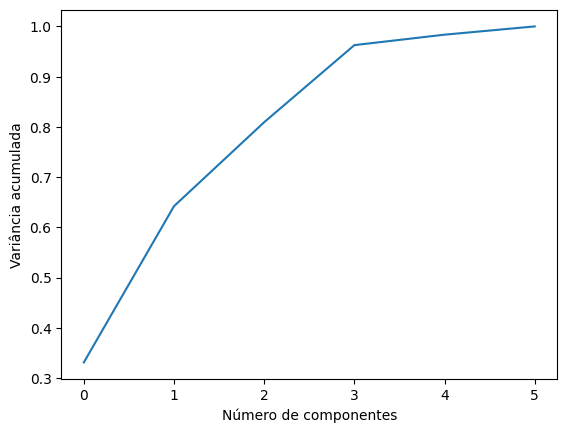

In [ ]:
pca = PCA()
pca.fit(X_scaled_df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de componentes')
plt.ylabel('Variância acumulada')


# Interpretação
## O primeiro componente (PC1) já explica ≈ 35% da variância total.

### Os dois primeiros componentes (PC1 + PC2) explicam ≈ 70%.

### Com 3 componentes, você já explica ≈ 90% da variância total.

### A partir do 4º componente, o ganho adicional é muito pequeno (chega perto de 100%).

Logo podemos reduzir o dataset para 3 componentes principais e ainda manter cerca de 90% da informação original.
Isso simplifica a análise e visualização sem perder muito conteúdo relevante.

In [ ]:
# 11) Conclusões simples e salvar arquivo processado
print("Resumo automático (exemplo):")
print("- Observações:", df.shape[0])
print("- Variáveis:", df.shape[1])
print("- Clusters formados (k):", best_k)
print("- Sugestões: verificar variáveis altamente correlacionadas, usar clusters para análise de regimes operacionais, testar relação cluster x falha (se houver).")

OUT_PATH = "/content/ai4i2020_processed_with_clusters.csv"
df.to_csv(OUT_PATH, index=False)
print("Arquivo processado salvo em:", OUT_PATH)


Resumo automático (exemplo):
- Observações: 10000
- Variáveis: 15
- Clusters formados (k): 4
- Sugestões: verificar variáveis altamente correlacionadas, usar clusters para análise de regimes operacionais, testar relação cluster x falha (se houver).
Arquivo processado salvo em: /content/ai4i2020_processed_with_clusters.csv


from IPython.display import Markdown

Markdown("""
## 💡 Sugestões de Melhoria para Análises Futuras

Com base nas análises realizadas e nas limitações observadas no notebook atual, seguem algumas sugestões para aprimorar o projeto em versões futuras:

---

### 📊 1. Aprimoramento da Análise Exploratória
- Realizar uma **análise estatística mais profunda**, incluindo medidas de tendência central e dispersão (média, mediana, desvio padrão, IQR).  
- Criar **visualizações mais específicas por categoria ou variável de interesse**, como:
  - Distribuições separadas por tipo de máquina.  
  - Séries temporais (caso haja dados de tempo) para observar padrões ao longo do tempo.  
- Incluir **correlações cruzadas** entre variáveis contínuas e categóricas.

---

### 🧮 2. Redução de Dimensionalidade (PCA)
- Avaliar o **número ótimo de componentes principais**, considerando o ponto de inflexão (“cotovelo”) no gráfico de variância acumulada.  
- Aplicar o PCA não apenas para visualização, mas também para **alimentar algoritmos de clusterização** com dados reduzidos (melhorando performance e interpretação).  
- Verificar **importância das variáveis originais** nas componentes principais.

---

### 🤖 3. Clusterização e Interpretação
- Testar **diferentes métodos de clusterização**:
  - `KMeans`, `DBSCAN`, `AgglomerativeClustering`, e até modelos baseados em densidade.  
- Utilizar **métricas de avaliação de agrupamento**, como:
  - *Silhouette Score*, *Davies-Bouldin Index* e *Calinski-Harabasz Score*.  
- Substituir a **matriz de confusão** por análises que relacionem os clusters às variáveis reais:
  - Porcentagem de falhas por cluster.  
  - Perfis médios de cada cluster.  
  - Visualizações 2D (ex.: PCA ou t-SNE) mostrando a separação dos grupos.

---

### ⚙️ 4. Preparação e Limpeza dos Dados
- Tratar **valores ausentes ou discrepantes** de maneira sistemática (remoção, substituição ou imputação).  
- Padronizar escalas e codificações antes de qualquer modelo.  
- Garantir que as variáveis tenham **significado físico ou operacional claro**.

---

### 📈 5. Visualizações Avançadas
- Criar **dashboards interativos** (ex.: `Plotly`, `Streamlit` ou `Dash`) para facilitar a exploração dos resultados.  
- Utilizar **heatmaps, pairplots e gráficos de correlação** para destacar padrões relevantes.  
- Explorar **mapas de calor temporais ou matriciais** se houver dados temporais ou espaciais.

---

### 🧠 6. Análise Preditiva (Extensão Futuras)
- Considerar um modelo supervisionado (como *Random Forest* ou *XGBoost*) para **prever falhas**, comparando o desempenho com o agrupamento não supervisionado.  
- Avaliar a **importância das variáveis** nesses modelos para entender o que mais influencia as falhas.

---

### 📘 7. Documentação e Reprodutibilidade
- Adicionar **comentários e explicações em cada célula**.  
- Criar uma **seção de conclusões** com os principais achados e limitações.  
- Salvar **versões intermediárias do dataset** após etapas de limpeza e transformação.

---

### 🚀 Conclusão
Essas melhorias permitirão análises mais robustas, interpretações mais ricas e resultados mais confiáveis, além de preparar o notebook para futuras expansões, como **modelos de predição e monitoramento contínuo das máquinas**.
""")
